In [1]:
from pathlib import Path

from maite_datasets.object_detection import MILCO

data_root = Path("./data")

# `base` fetches the archive once; the two calls below export each split for datamaite.
MILCO(root=data_root, image_set="base", download=True)
MILCO(root=data_root, image_set="train", as_datamaite=True)
MILCO(root=data_root, image_set="operational", as_datamaite=True)

reference_path = data_root / "milco_datamaite_train"
operational_path = data_root / "milco_datamaite_operational"

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/maite_datasets/_datamaite.py:497: UserWarning: datamaite reads back only ['test', 'train', 'val'] splits; exporting image_set 'operational' as 'train'.
  dm_ds = _convert_od_dataset(raw_ds, split=split)


In [2]:
import json
from collections import Counter

for name, path in (("reference", reference_path), ("operational", operational_path)):
    annotations = json.loads((path / "annotations" / "instances.json").read_text())
    years = [Path(img["file_name"]).stem.split("_")[-1] for img in annotations["images"]]
    first_index = {}
    for idx, year in enumerate(years):
        first_index.setdefault(year, idx)
    print(f"{name:<12} {len(years):>4} frames   {dict(Counter(years))}")
    print(f"{'':<12} first index of each year: {first_index}")

reference     261 frames   {'2015': 120, '2017': 93, '2021': 48}
             first index of each year: {'2015': 0, '2017': 120, '2021': 213}
operational   909 frames   {'2010': 345, '2018': 564}
             first index of each year: {'2010': 0, '2018': 345}


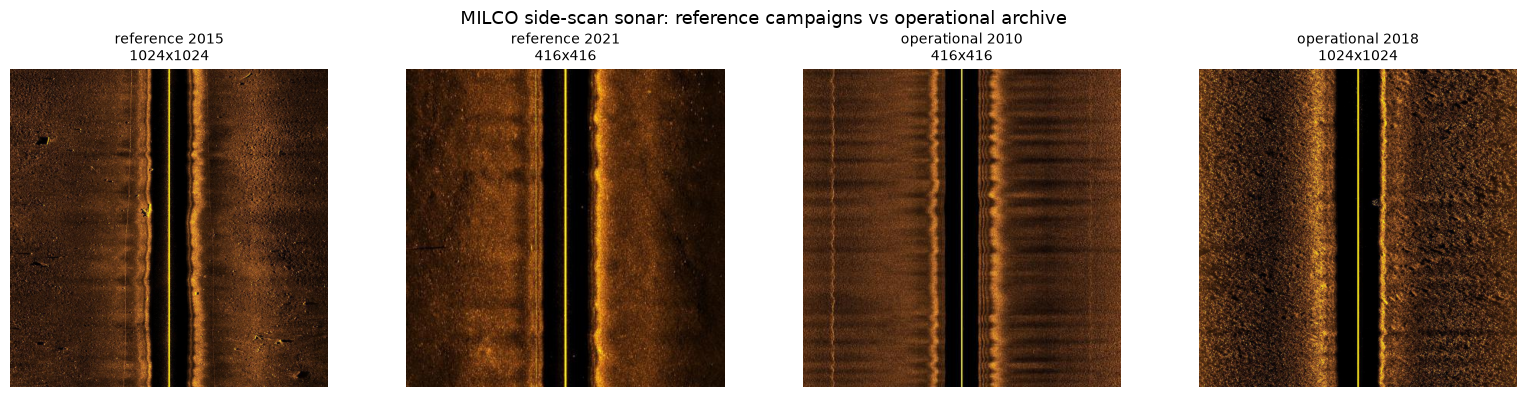

In [3]:
import matplotlib.pyplot as plt
import numpy as np

samples = {
    "reference 2015": MILCO(root=data_root, image_set="train")[0][0],
    "reference 2021": MILCO(root=data_root, image_set="train")[255][0],
    "operational 2010": MILCO(root=data_root, image_set="operational")[0][0],
    "operational 2018": MILCO(root=data_root, image_set="operational")[500][0],
}

fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
for ax, (title, image) in zip(axes, samples.items(), strict=True):
    ax.imshow(np.transpose(np.asarray(image), (1, 2, 0)))
    ax.set_title(f"{title}\n{np.asarray(image).shape[1]}x{np.asarray(image).shape[2]}", fontsize=10)
    ax.axis("off")
fig.suptitle("MILCO side-scan sonar: reference campaigns vs operational archive", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
from dataeval_flow import PipelineConfig
from dataeval_flow.config import (
    CocoDatasetConfig,
    PreprocessingStep,
    PreprocessorConfig,
    SourceConfig,
)
from dataeval_flow.config.extractors import BoVWExtractorConfig

preprocessor_config = PreprocessorConfig(
    name="sonar",
    steps=[PreprocessingStep(step="Resize", params={"size": [256, 256], "antialias": True})],
)

# BoVW fits one vocabulary across every source a task compares, so the reference and the
# operational archive are described in the same visual words. A per-source vocabulary
# would report drift between a dataset and itself.
extractor_config = BoVWExtractorConfig(name="bovw", vocab_size=256, batch_size=32, preprocessor="sonar")

reference_dataset = CocoDatasetConfig(name="reference", path=str(reference_path))
operational_dataset = CocoDatasetConfig(name="operational", path=str(operational_path))

In [5]:
from dataeval_flow import run_task
from dataeval_flow.config import TaskConfig
from dataeval_flow.workflows.drift_monitoring import (
    ChunkingConfig,
    DriftDetectorKNeighbors,
    DriftDetectorMMD,
    DriftDetectorUnivariate,
    DriftMonitoringConfig,
    DriftMonitoringHealthThresholds,
)

drift_task = TaskConfig(
    name="milco-drift-overall",
    workflow="milco-drift",
    sources=["ref_src", "ops_src"],
    extractor="bovw",
)

config = PipelineConfig(
    datasets=[reference_dataset, operational_dataset],
    sources=[
        SourceConfig(name="ref_src", dataset="reference"),
        SourceConfig(name="ops_src", dataset="operational"),
    ],
    preprocessors=[preprocessor_config],
    extractors=[extractor_config],
    workflows=[
        DriftMonitoringConfig(
            name="milco-drift",
            detectors=[
                DriftDetectorKNeighbors(k=10, chunking=ChunkingConfig(chunk_size=200, threshold_multiplier=4.0)),
                DriftDetectorMMD(n_permutations=100, chunking=ChunkingConfig(chunk_size=200, threshold_multiplier=4.0)),
                DriftDetectorUnivariate(test="cvm"),  # non-chunked overall test
            ],
            health_thresholds=DriftMonitoringHealthThresholds(
                chunk_drift_pct_warning=15.0,  # warn if >15% of chunks drift
                consecutive_chunks_warning=2,  # warn on 2+ consecutive drifted chunks
            ),
        ),
    ],
    tasks=[drift_task],
)

In [6]:
result = run_task(drift_task, config, cache_dir=Path("./cache"))

In [7]:
print(result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 261 ITEMS, TEST: 909 ITEMS.
  Timestamp:    2026-09-25T21:35:36.834832+00:00
  Duration:     189.80s
  Source:       ref_src (reference)
                ops_src (operational)
  Model:        bovw (bovw)
  Preprocessor: sonar
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (chunk_size=200, z=4.0) ...........................................   [ok]
  MMD (chunk_size=200, z=4.0) ...................................................   [!!]
  CVM Univariate ................................................................   [!!]

  Health: 2 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (CHUNK_SIZE=200, Z=4.0)
  0/4 chunks drifted (0%) | max consecutive: 0

  Chunk      Distance                                  Status
  ---------  --------  ------------------------------  ------
  [0:199]      0.7270  ███████████████████████████░░░  ok
  [200:399]    0.6156  ████████

In [8]:
from dataeval_flow.config import ViewConfig, ViewOperation

control_task = TaskConfig(
    name="milco-drift-control",
    workflow="milco-drift-control",
    sources=["y2015_src", "y2017_2021_src"],
    extractor="bovw",
)

control_config = PipelineConfig(
    datasets=[reference_dataset],
    views=[
        ViewConfig(
            name="y2015", operations=[ViewOperation(type="Indices", params={"indices": {"start": 0, "stop": 120}})]
        ),
        ViewConfig(
            name="y2017_2021",
            operations=[ViewOperation(type="Indices", params={"indices": {"start": 120, "stop": 261}})],
        ),
    ],
    sources=[
        SourceConfig(name="y2015_src", dataset="reference", view="y2015"),
        SourceConfig(name="y2017_2021_src", dataset="reference", view="y2017_2021"),
    ],
    preprocessors=[preprocessor_config],
    extractors=[extractor_config],
    workflows=[
        DriftMonitoringConfig(
            name="milco-drift-control",
            # No chunking: 141 incoming frames forms a single window to test baseline variation.
            detectors=[
                DriftDetectorKNeighbors(k=10),
                DriftDetectorMMD(n_permutations=100),
                DriftDetectorUnivariate(test="cvm"),
            ],
        ),
    ],
    tasks=[control_task],
)

control_result = run_task(control_task, control_config, cache_dir=Path("./cache"))
print(control_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 120 ITEMS, TEST: 141 ITEMS.
  Timestamp:    2026-09-25T21:36:22.561814+00:00
  Duration:     44.95s
  Source:       y2015_src (reference[y2015])
                y2017_2021_src (reference[y2017_2021])
  Model:        bovw (bovw)
  Preprocessor: sonar
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors ...................................................................   [!!]
  MMD ...........................................................................   [!!]
  CVM Univariate ................................................................   [!!]

  Health: 3 warning(s) [!!] — review flagged findings

  K-NEIGHBORS
  K-Neighbors: distance=0.8184, threshold=0.05, p=0.0

  distance   0.8184
  threshold  0.05
  metric     knn_distance
  p_val      0.0

  MMD
  MMD: distance=0.2148, threshold=0.05, p=0.0

  distance   0.2148
  threshold  0.05
  metric     mmd2
  p_val      0

In [9]:
import polars as pl

pl.Config.set_tbl_hide_dataframe_shape(True)

raw = result.output.raw
print(f"Reference size: {raw.reference_size}")
print(f"Test size:      {raw.test_size}")
print()

for method, det_result in raw.detectors.items():
    print(f"── {method} ({det_result['metric_name']}) ──")
    print(f"  Overall drifted: {det_result['drifted']}")
    print(f"  Distance:        {det_result['distance']:.6g}")

    chunks = det_result.get("chunks", [])
    if chunks:
        df = pl.DataFrame(chunks).select("key", "value", "lower_threshold", "upper_threshold", "drifted")
        print(df)
    print()

Reference size: 261
Test size:      909

── kneighbors (knn_distance) ──
  Overall drifted: False
  Distance:        0.626813
┌───────────┬──────────┬─────────────────┬─────────────────┬─────────┐
│ key       ┆ value    ┆ lower_threshold ┆ upper_threshold ┆ drifted │
│ ---       ┆ ---      ┆ ---             ┆ ---             ┆ ---     │
│ str       ┆ f64      ┆ f64             ┆ f64             ┆ bool    │
╞═══════════╪══════════╪═════════════════╪═════════════════╪═════════╡
│ [0:199]   ┆ 0.727015 ┆ 0.204903        ┆ 0.800545        ┆ false   │
│ [200:399] ┆ 0.61557  ┆ 0.204903        ┆ 0.800545        ┆ false   │
│ [400:599] ┆ 0.544811 ┆ 0.204903        ┆ 0.800545        ┆ false   │
│ [600:908] ┆ 0.619854 ┆ 0.204903        ┆ 0.800545        ┆ false   │
└───────────┴──────────┴─────────────────┴─────────────────┴─────────┘

── mmd (mmd2) ──
  Overall drifted: True
  Distance:        0.208306
┌───────────┬──────────┬─────────────────┬─────────────────┬─────────┐
│ key       ┆ value    

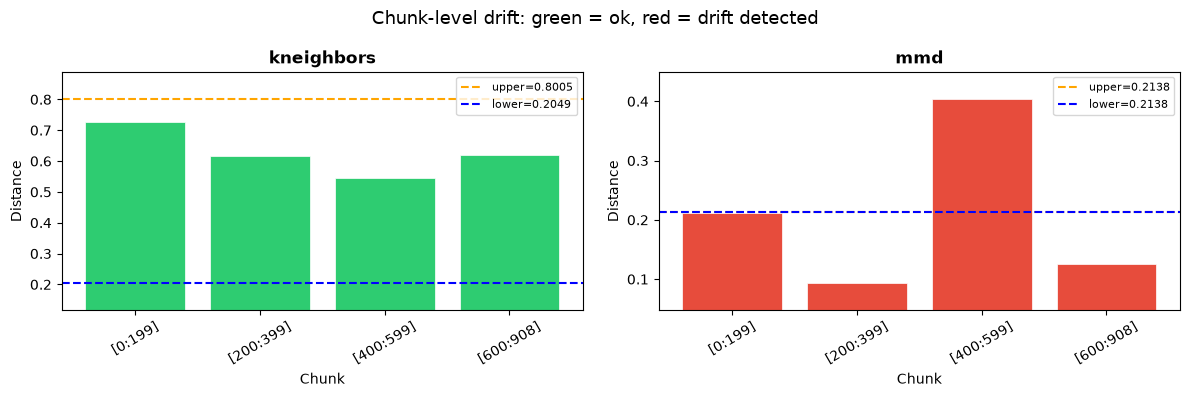

In [10]:
# Only plot detectors that have chunk results
chunked_methods = [m for m, r in raw.detectors.items() if r.get("chunks")]
fig, axes = plt.subplots(1, len(chunked_methods), figsize=(6 * len(chunked_methods), 4))
if len(chunked_methods) == 1:
    axes = [axes]  # type: ignore[list-item]

for ax, method in zip(axes, chunked_methods, strict=True):
    chunks = raw.detectors[method]["chunks"]  # type: ignore[typeddict-item]

    labels = [c["key"] for c in chunks]
    values = [c["value"] for c in chunks]
    colors = ["#e74c3c" if c["drifted"] else "#2ecc71" for c in chunks]

    ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.5)

    # Draw threshold lines and expand y-axis to include them
    upper_thresh = chunks[0].get("upper_threshold")
    lower_thresh = chunks[0].get("lower_threshold")
    all_y = list(values)
    if upper_thresh is not None:
        ax.axhline(
            y=upper_thresh,
            color="orange",
            linestyle="--",
            linewidth=1.5,
            label=f"upper={upper_thresh:.4g}",
        )
        all_y.append(upper_thresh)
    if lower_thresh is not None:
        ax.axhline(
            y=lower_thresh,
            color="blue",
            linestyle="--",
            linewidth=1.5,
            label=f"lower={lower_thresh:.4g}",
        )
        all_y.append(lower_thresh)
    y_min, y_max = min(all_y), max(all_y)
    margin = (y_max - y_min) * 0.15 or abs(y_max) * 0.1 or 0.01
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    ax.legend(fontsize=8)
    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.set_ylabel("Distance")
    ax.set_xlabel("Chunk")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Chunk-level drift: green = ok, red = drift detected", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:600] + "\n...")

JSON output: 28534 characters
{
  "kind": "workflow",
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-09-25T21:35:36.834832Z",
    "dataset_id": "reference,operational",
    "label_source": "annotations",
    "model_id": "bovw (bovw)",
    "preprocessor_id": "sonar",
    "selection_id": null,
    "source_descriptions": [
      "ref_src (reference)",
      "ops_src (operational)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "ref_src",
          "dataset": "reference",
          "dataset_config": {
            "format": "coco",
            "name": "reference",
            "path"
...
